In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import umap
import json

In [4]:
# Load the original training labels
with open("../data/SOMD 2026/subtask 1/train_labels.json", "r") as f:
    train_labels = json.load(f)

file_to_load = "/home/aalkan/Documents/coref-shared-task/SOMD-2026/data/SOMD 2026/subtask 1/train_data.jsonl"
with open(file_to_load, 'r') as f:
    train_data = [json.loads(l) for l in list(f)]

In [19]:
def id2mention(_list, data):
    mention_list = []
    for mention_id in _list:
        for d in data:
            if d["mention_id"] == mention_id:
                mention = d["mention"]
                mention_list.append(mention)
    mention_list = list(set(mention_list))
    return mention_list

In [35]:
# ---- Your data: list of clusters; each cluster is a list of coreferring mentions
clusters = []

for idx_list in train_labels[:5]:
    mention_list = id2mention(idx_list, train_data)
    clusters.append(mention_list)

In [36]:
clusters

[['MatLab', 'Matlab', 'MATLAB', 'MATLB'],
 ['voicebox'],
 ['PASW Statistic',
  'SPSS',
  'PASW Statistics',
  'Statistical Package for Social Science',
  'SPSS Statistics',
  'statistical package for social sciences',
  'Statistical Package for Social Sciences',
  'Statistical Package for the Social Sciences',
  'SPSS statistics',
  'Software Package for Statistical Analysis',
  'PASW',
  'Statistical package for Social Sciences',
  'Statistical Product and Service Solutions',
  'SPSS Dimensions',
  'statistical package for social science',
  'Statistical Package for the Social Science',
  'Statistical Program for the Social Sciences'],
 ['Statistical Analysis Systems',
  'SAS Lab Pro',
  'SAS Enterprise Guide',
  'Statistical Analysis System',
  'SAS',
  'statistical analyses software'],
 ['AccuTyping']]

/home/aalkan/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


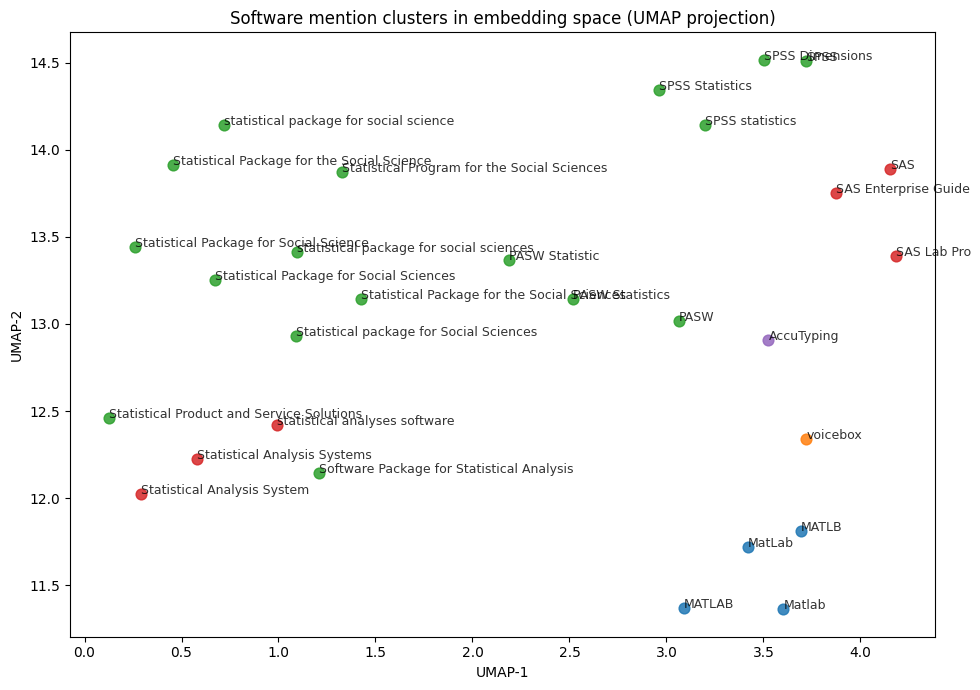

In [ ]:
# ---- Flatten mentions + keep cluster ids
mentions = []
cluster_ids = []
for cid, cluster in enumerate(clusters):
    for m in cluster:
        mentions.append(m)
        cluster_ids.append(cid)

# ---- Embed mentions
model = SentenceTransformer("all-MiniLM-L6-v2")  # small & solid baseline
X = model.encode(mentions, normalize_embeddings=True)  # (N, d)

# ---- Project to 2D
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric="cosine", random_state=42)
X2 = reducer.fit_transform(X)  # (N, 2)

# ---- Plot (same cluster => same color)
plt.figure(figsize=(10, 7))
cluster_ids = np.array(cluster_ids)
unique_cids = np.unique(cluster_ids)

for cid in unique_cids:
    idx = cluster_ids == cid
    plt.scatter(X2[idx, 0], X2[idx, 1], s=60, alpha=0.85, label=f"Cluster {cid}")

# Optional: annotate points with mention text (can get cluttered)
for (x, y), text in zip(X2, mentions):
    plt.text(x, y, text, fontsize=9, alpha=0.8)

plt.title("Software mention clusters in embedding space (UMAP projection)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
#plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [5]:
train_labels

[['bb3d24e7ce',
  '90316eca5f',
  'd2c3701a80',
  '2634619832',
  '1296ca5490',
  'e92cc8aa77',
  '31a059b2b8',
  '2f713d2cc3',
  '9f5fe53a62',
  '486bdac576',
  '97d68e9fd4',
  '917758498c',
  '12a9da03b2',
  '60d23c5eb4',
  '4e5013ad8d',
  'ba943531ea',
  '9e43d16a7f',
  '335fb6e406',
  'e241067857',
  'd7bf9ada87',
  '1445823bb1',
  '4e79a6f4a3',
  'bec63405bb',
  'e5f493e946',
  '114fcfed9b',
  'f049c91597',
  '8f8233aed1',
  '7d5f0ef1f7',
  '7904ae90ef',
  '52185ec094',
  '90e376365b',
  'd1de736aef',
  'ed1211f591',
  'db43efdb01',
  '556500baf0',
  '73174576ae',
  '8933605a62',
  '664417d4e7',
  'a5a5e45806',
  '0b94770024',
  'a069043245',
  'dfce0b5ecd',
  '4760bc7182',
  '22a85fc47b',
  '79d58a62e8',
  '701ee90e5f',
  '32e97cc316',
  '38bea5314e',
  'c5e1a65590',
  '4f9f720d35',
  'cd10fedd0b',
  '170383847b',
  '2b09a024c9',
  '82f601991d',
  'b2de47b23c',
  '03109b0b63',
  '61f40aecd7',
  '2b4a7fb3dd',
  '0893cac93d',
  'abd52d12bf',
  '9e47496de5',
  '25d500590f',
  'ca5fb